# Heart Disease UCI - EDA
Beginner-friendly EDA on 303 patient records, 13 clinical features.

Imports
Libraries needed for data handling and plotting.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

Load dataset
Loaded directly from a public URL, no manual download needed.

In [21]:
url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Shape & info
Basic inspection: rows, columns, data types.

In [22]:
print("Shape:", df.shape)
df.info()

Shape: (303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


Summary stats
Mean, std, min/max for every numeric column.

In [23]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Missing values
Checking if any column has nulls.

In [24]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate rows
Even clean-looking datasets can have repeated rows.

In [25]:
print("Duplicate rows:", df.duplicated().sum())
df[df.duplicated()]

Duplicate rows: 1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


Drop duplicates
Removing repeated records before analysis.

In [26]:
df = df.drop_duplicates()
print("Shape after dedup:", df.shape)

Shape after dedup: (302, 14)


Target value counts
target: 1 = disease, 0 = no disease. Checking class balance.

In [27]:
df["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

Target distribution plot
Visual version of the counts above.

C:\Users\Ibrahim Khan\AppData\Local\Temp\ipykernel_11736\910878470.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="target", palette="Set2")


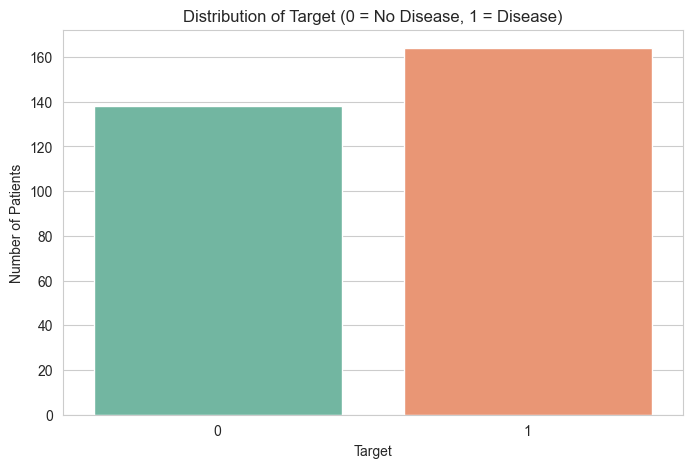

In [28]:
sns.countplot(data=df, x="target", palette="Set2")
plt.title("Distribution of Target (0 = No Disease, 1 = Disease)")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.show()

Numeric feature histograms
How age, blood pressure, cholesterol, etc. are distributed.

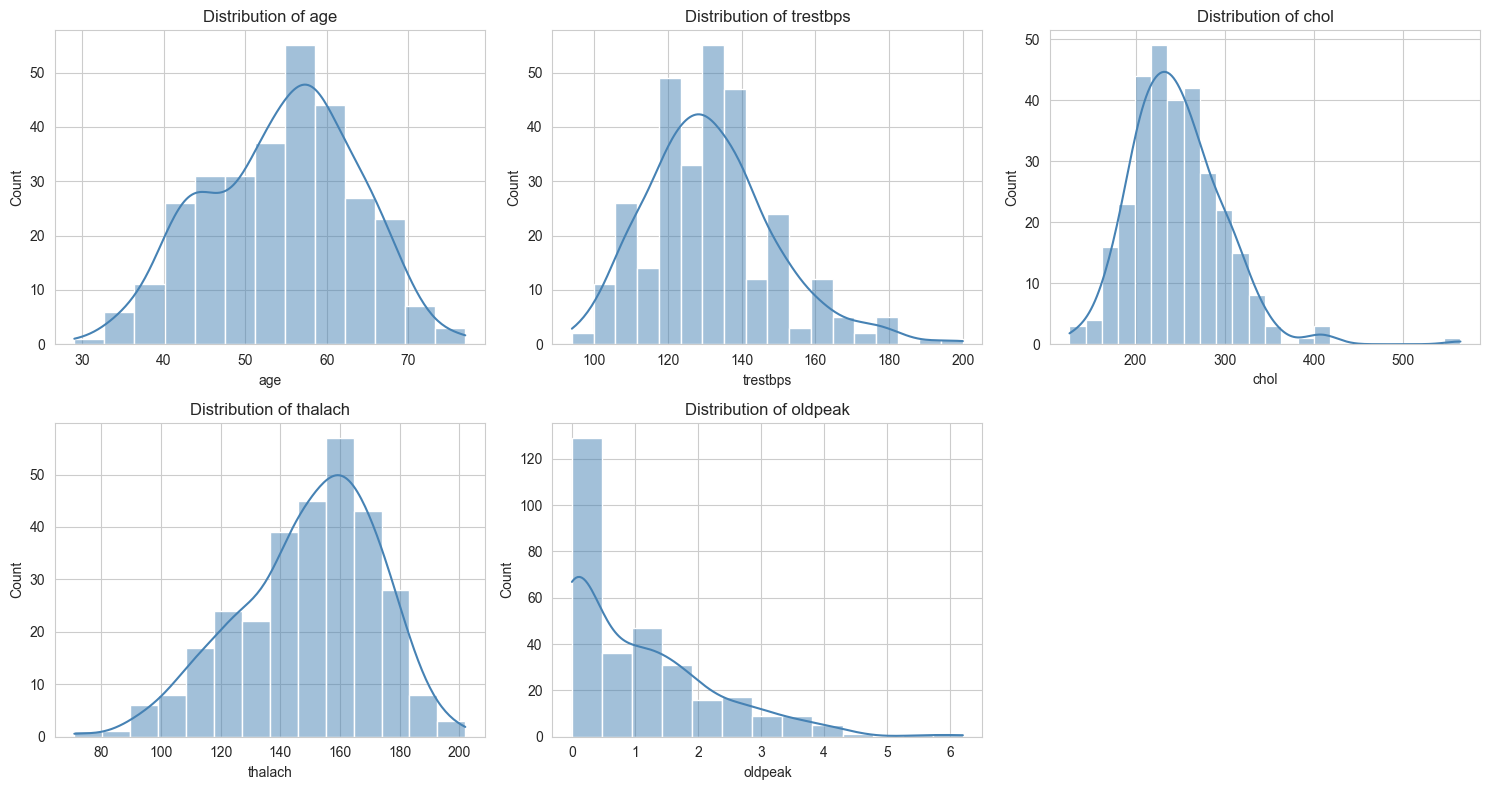

In [29]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

Boxplots
Boxplots make outliers easy to spot.

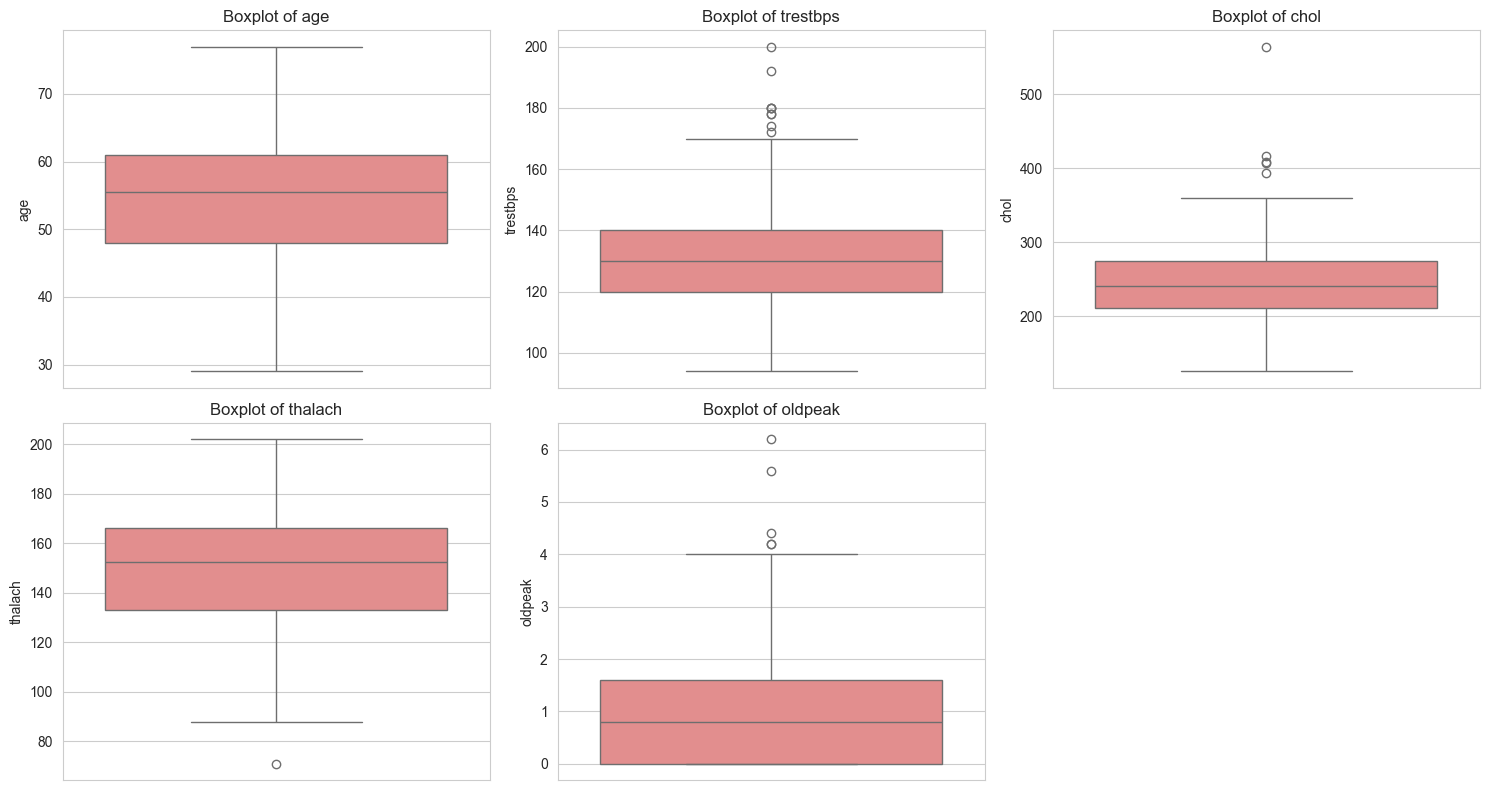

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(y=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot of {col}")

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

Categorical feature counts
Distribution of sex, chest pain type, and other categorical fields.

C:\Users\Ibrahim Khan\AppData\Local\Temp\ipykernel_11736\1419889767.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette="pastel")
C:\Users\Ibrahim Khan\AppData\Local\Temp\ipykernel_11736\1419889767.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette="pastel")
C:\Users\Ibrahim Khan\AppData\Local\Temp\ipykernel_11736\1419889767.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette="pastel")
C:\Users\Ibrahim Khan\AppData\Local\Temp\ip

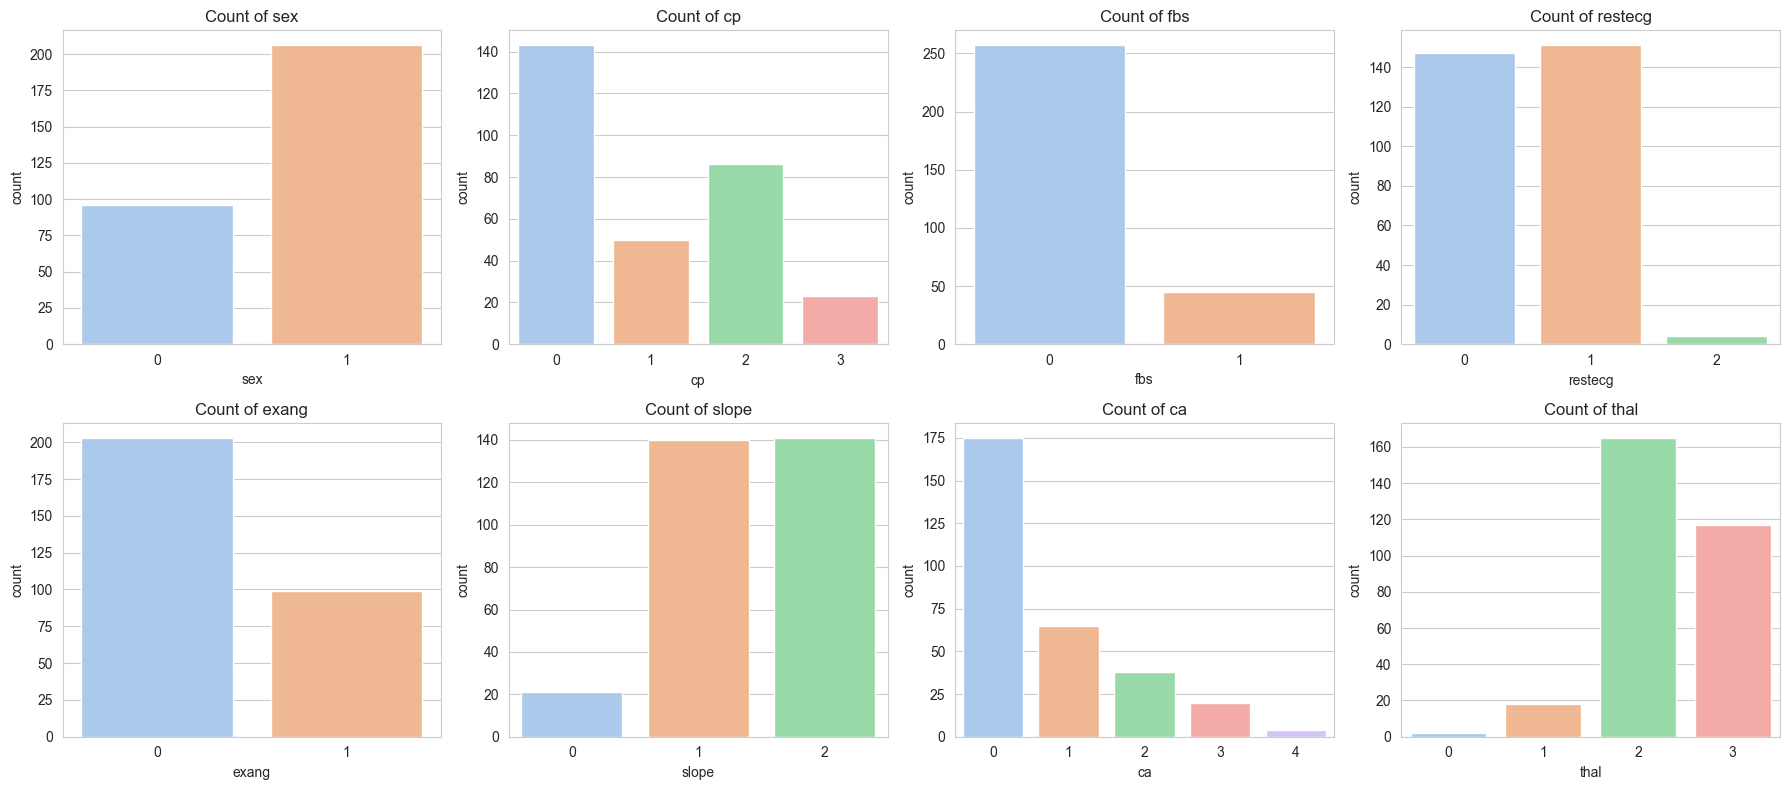

In [31]:
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, ax=axes[i], palette="pastel")
    axes[i].set_title(f"Count of {col}")

plt.tight_layout()
plt.show()

Age vs target
Does age differ between disease and no-disease groups?

C:\Users\Ibrahim Khan\AppData\Local\Temp\ipykernel_11736\1611927759.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y="age", palette="Set2")


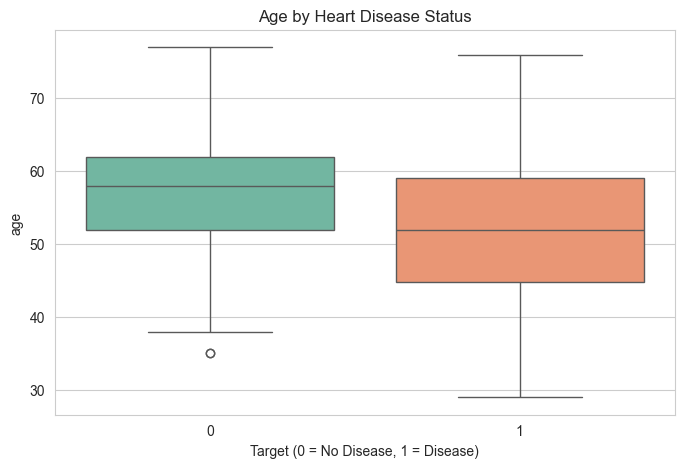

In [32]:
sns.boxplot(data=df, x="target", y="age", palette="Set2")
plt.title("Age by Heart Disease Status")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.show()

Max heart rate vs target
Comparing thalach across the two groups.

C:\Users\Ibrahim Khan\AppData\Local\Temp\ipykernel_11736\1280239173.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y="thalach", palette="Set2")


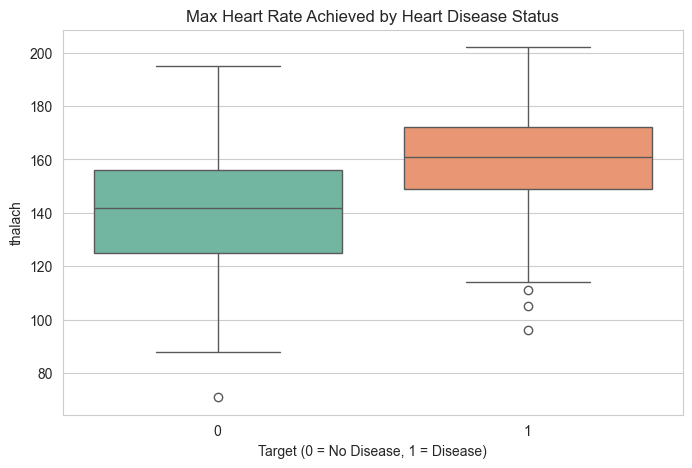

In [33]:
sns.boxplot(data=df, x="target", y="thalach", palette="Set2")
plt.title("Max Heart Rate Achieved by Heart Disease Status")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.show()

Chest pain type vs target
Which chest pain type is more common in disease patients.

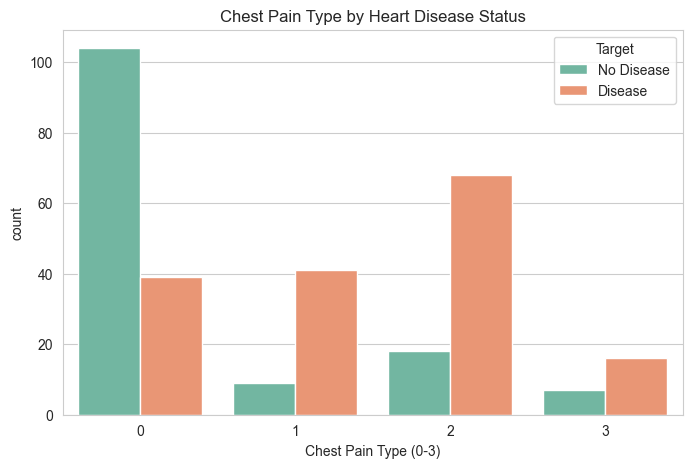

In [34]:
sns.countplot(data=df, x="cp", hue="target", palette="Set2")
plt.title("Chest Pain Type by Heart Disease Status")
plt.xlabel("Chest Pain Type (0-3)")
plt.legend(title="Target", labels=["No Disease", "Disease"])
plt.show()

Sex vs target
Disease distribution across male/female patients.

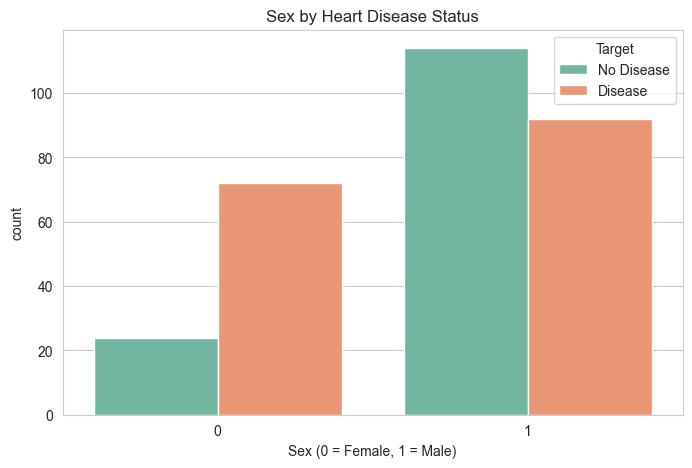

In [35]:
sns.countplot(data=df, x="sex", hue="target", palette="Set2")
plt.title("Sex by Heart Disease Status")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.legend(title="Target", labels=["No Disease", "Disease"])
plt.show()

Exercise-induced angina vs target
Checking if exang relates to heart disease presence.

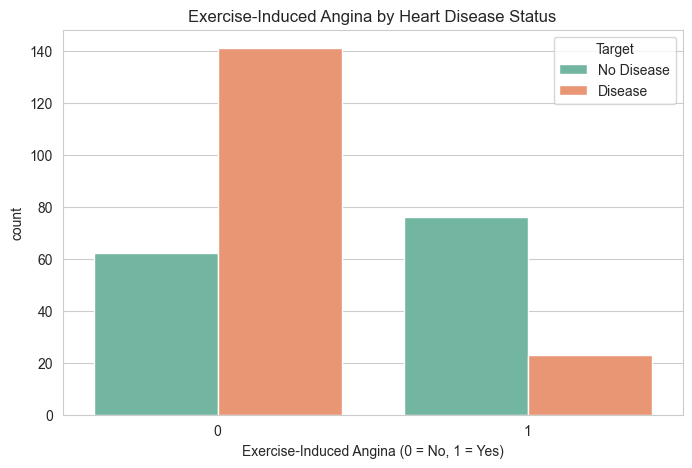

In [36]:
sns.countplot(data=df, x="exang", hue="target", palette="Set2")
plt.title("Exercise-Induced Angina by Heart Disease Status")
plt.xlabel("Exercise-Induced Angina (0 = No, 1 = Yes)")
plt.legend(title="Target", labels=["No Disease", "Disease"])
plt.show()

Correlation heatmap
How strongly every numeric feature relates to every other.

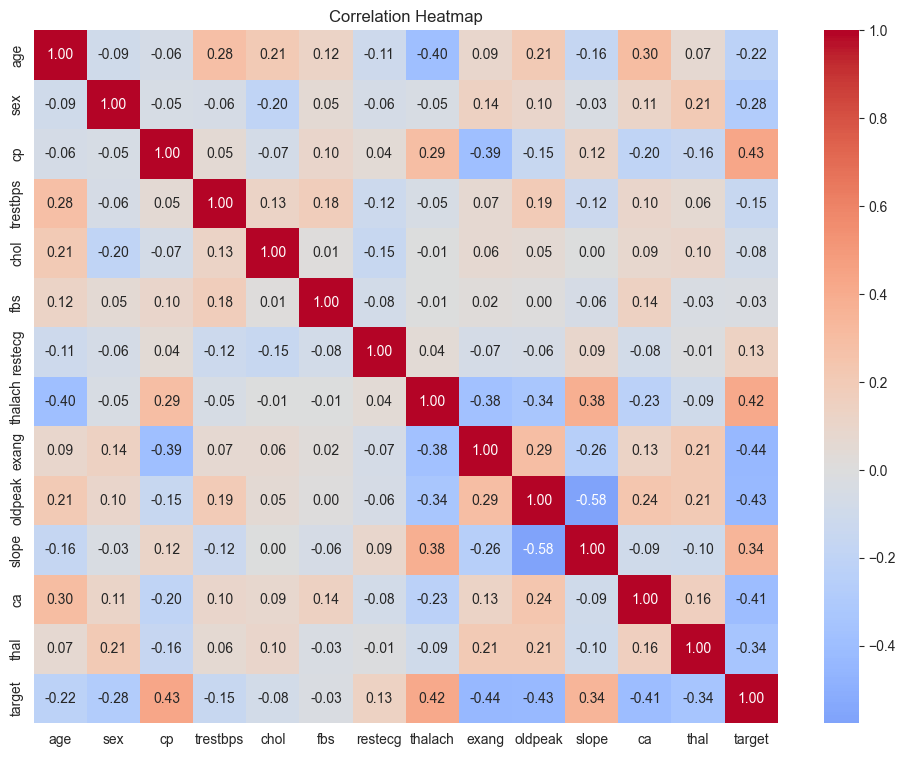

In [37]:
plt.figure(figsize=(12, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

Top correlations with target
Ranking features by how strongly they relate to target.

In [38]:
corr["target"].sort_values(ascending=False)

target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64